In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

In [ ]:
# @title Download the data

import os, requests, tarfile

fnames = ["kay_labels.npy", "kay_labels_val.npy", "kay_images.npz"]
urls = ["https://osf.io/r638s/download",
        "https://osf.io/yqb3e/download",
        "https://osf.io/ymnjv/download"]

for fname, url in zip(fnames, urls):
  if not os.path.isfile(fname):
    try:
      r = requests.get(url)
    except requests.ConnectionError:
      print("!!! Failed to download data !!!")
    else:
      if r.status_code != requests.codes.ok:
        print("!!! Failed to download data !!!")
      else:
        print(f"Downloading {fname}...")
        with open(fname, "wb") as fid:
          fid.write(r.content)
        print(f"Download {fname} completed!")

Download kay_labels_val.npy completed!


In [ ]:
# @title
with np.load(fname) as dobj:
  dat = dict(**dobj)
labels = np.load('kay_labels.npy')
val_labels = np.load('kay_labels_val.npy')


`labels` is a 4 by stim array of class names:  
- row 3 has the labels predicted by a deep neural network (DNN) trained on Imagenet
- rows 0-2 correspond to different levels of the wordnet hierarchy for the DNN predictions

In [ ]:
# @title
print(dat.keys())

dict_keys(['stimuli', 'stimuli_test', 'responses', 'responses_test', 'roi', 'roi_names'])


`dat` has the following fields:  
- `stimuli`: stim x i x j array of grayscale stimulus images
- `stimuli_test`: stim x i x j array of grayscale stimulus images in the test set  
- `responses`: stim x voxel array of z-scored BOLD response amplitude
- `responses_test`:  stim x voxel array of z-scored BOLD response amplitude in the test set  
- `roi`: array of voxel labels
- `roi_names`: array of names corresponding to voxel labels

In [ ]:
print(f"stimuli shape = {dat["stimuli"].shape}")
print(f"responses shape = {dat["responses"].shape}")
print(f"roi shape = {dat["roi"].shape}")
print(f"roi_names shape = {dat["roi_names"].shape}")

stimuli shape = (1750, 128, 128)
responses shape = (1750, 8428)
roi shape = (8428,)
roi_names shape = (8,)


In [ ]:
display(dict(zip(range(8), dat["roi_names"])))

{0: np.str_('Other'),
 1: np.str_('V1'),
 2: np.str_('V2'),
 3: np.str_('V3'),
 4: np.str_('V3A'),
 5: np.str_('V3B'),
 6: np.str_('V4'),
 7: np.str_('LatOcc')}

This is the number of voxels in each ROI. Note that `"Other"` voxels have been removed from this version of the dataset:

In [ ]:
# @title
dict(zip(dat["roi_names"], np.bincount(dat["roi"])))

{np.str_('Other'): np.int64(0),
 np.str_('V1'): np.int64(1294),
 np.str_('V2'): np.int64(2083),
 np.str_('V3'): np.int64(1790),
 np.str_('V3A'): np.int64(484),
 np.str_('V3B'): np.int64(314),
 np.str_('V4'): np.int64(1535),
 np.str_('LatOcc'): np.int64(928)}

Each stimulus is a 128 x 128 grayscale array:

Each stimulus is associated with a pattern of BOLD response across voxels in visual cortex:

The training/validation splits from the original paper are retained, so the 120 test stimuli and responses are in separate data structures:

In [ ]:
# @title
# Example: Find the ROI for the first 5 voxels
for voxel_idx in range(5):
    roi_label = dat["roi"][voxel_idx]
    roi_name = dat["roi_names"][roi_label]
    print(f"Voxel {voxel_idx}: ROI Label = {roi_label}, ROI Name = {roi_name}")

# You can also get a list of all ROI names corresponding to each voxel
voxel_roi_names = [dat["roi_names"][label] for label in dat["roi"]]
print(f"\nROI names for all {len(voxel_roi_names)} voxels (first 10):\n{voxel_roi_names[:10]}")

Voxel 0: ROI Label = 3, ROI Name = V3
Voxel 1: ROI Label = 3, ROI Name = V3
Voxel 2: ROI Label = 3, ROI Name = V3
Voxel 3: ROI Label = 3, ROI Name = V3
Voxel 4: ROI Label = 3, ROI Name = V3

ROI names for all 8428 voxels (first 10):
[np.str_('V3'), np.str_('V3'), np.str_('V3'), np.str_('V3'), np.str_('V3'), np.str_('V3'), np.str_('V3'), np.str_('V3'), np.str_('V3'), np.str_('V3')]


In [ ]:
# @title
import pandas as pd
import seaborn as sns

# Get unique ROI labels that have voxels
# 'Other' (label 0) has 0 voxels based on previous output, so we exclude it.
valid_roi_labels = [label for label, count in enumerate(np.bincount(dat["roi"])) if count > 0]
valid_roi_names = [dat["roi_names"][label] for label in valid_roi_labels]

# Initialize a list to store average responses for each stimulus
avg_roi_responses_data = []

# Iterate through each stimulus
num_stimuli = dat["responses"].shape[0]
for stim_idx in range(num_stimuli):
    stim_responses = dat["responses"][stim_idx, :]

    # Dictionary to store average response for each ROI for the current stimulus
    stim_avg_responses = {'stim_idx': stim_idx, 'stim_label': labels[-1, stim_idx]}
    for roi_label, roi_name in zip(valid_roi_labels, valid_roi_names):
        # Get indices of voxels belonging to the current ROI
        voxel_indices_in_roi = np.where(dat["roi"] == roi_label)[0]

        # Calculate the mean response for these voxels for the current stimulus
        if len(voxel_indices_in_roi) > 0:
            avg_response = np.mean(stim_responses[voxel_indices_in_roi])
        else:
            avg_response = np.nan

        stim_avg_responses[roi_name] = avg_response

    avg_roi_responses_data.append(stim_avg_responses)

# Convert to pandas DataFrame
df_avg_roi_responses = pd.DataFrame(avg_roi_responses_data)

print("DataFrame with average ROI responses created. Displaying head:")
display(df_avg_roi_responses.head())

DataFrame with average ROI responses created. Displaying head:


,stim_idx,stim_label,V1,V2,V3,V3A,V3B,V4,LatOcc
0,0,croquet ball,-0.238602,-0.120704,-0.044963,-0.137893,-0.086964,-0.031129,0.001831
1,1,bubble,-0.366203,-0.361294,-0.318463,-0.171746,-0.226066,-0.103376,-0.141801
2,2,komondor,0.057211,0.076150,0.075690,-0.024797,-0.112535,0.098680,0.001206
3,3,tailed frog,-0.150679,-0.165336,-0.082213,-0.165484,-0.034683,0.004479,0.039795
4,4,Pomeranian,-0.232711,-0.077699,0.022789,-0.140222,-0.107827,-0.041820,0.000605


## Representation Dissimilarity Matrix

### Plotting functions

In [ ]:
def plot_corr_matrix(rdm, ax=None, show=False):
  """Plot dissimilarity matrix

  Args:
    rdm (numpy array): n_stimuli x n_stimuli representational dissimilarity
      matrix
    ax (matplotlib axes): axes onto which to plot

  Returns:
    nothing

  """
  if ax is None:
    ax = plt.gca()
  image = ax.imshow(rdm, vmin=0.0, vmax=2.0)
  ax.set_xticks([])
  ax.set_yticks([])
  cbar = plt.colorbar(image, ax=ax, label='dissimilarity')
  if show:
    plt.show()

def plot_multiple_rdm(rdm_dict):
  """Draw multiple subplots for each RDM in rdm_dict."""
  fig, axs = plt.subplots(1, len(rdm_dict),
                          figsize=(4 * len(resp_dict), 3.5))

  # Compute RDM's for each set of responses and plot
  for i, (label, rdm) in enumerate(rdm_dict.items()):

    image = plot_corr_matrix(rdm, axs[i])
    axs[i].set_title(label)
  plt.show()

def plot_rdm_rdm_correlations(rdm_sim):
  """Draw a bar plot showing between-RDM correlations."""
  f, ax = plt.subplots()
  ax.bar(rdm_sim.keys(), rdm_sim.values())
  ax.set_xlabel('Deep network model layer')
  ax.set_ylabel('Correlation of model layer RDM\nwith mouse V1 RDM')
  plt.show()

### Helper functions

In [ ]:
import scipy
from scipy.stats import zscore

def RDM(resp):
  """Compute the representational dissimilarity matrix (RDM)

  Args:
    resp (ndarray): S x N matrix with population responses to
      each stimulus in each row

  Returns:
    ndarray: S x S representational dissimilarity matrix
  """

  # z-score responses to each stimulus
  zresp = zscore(resp, axis=1)

  # Compute RDM
  RDM = 1 - (zresp @ zresp.T) / zresp.shape[1]

  return RDM


# Compute RDMs for each layer
rdm_dict = {label: RDM(resp) for label, resp in resp_dict.items()}

# Plot RDMs
with plt.xkcd():
  plot_multiple_rdm(rdm_dict)

### RSA

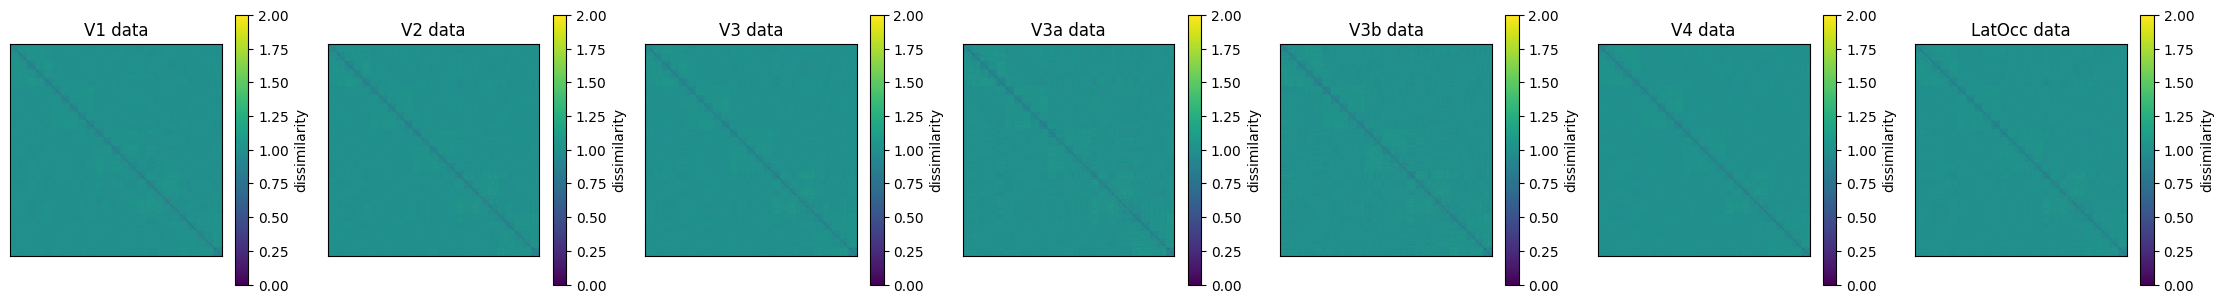

In [ ]:
resp_v1 = dat["responses"][:,dat["roi"] == 1]
resp_v2 = dat["responses"][:,dat["roi"] == 2]
resp_v3 = dat["responses"][:,dat["roi"] == 3]
resp_v3a = dat["responses"][:,dat["roi"] == 4]
resp_v3b = dat["responses"][:,dat["roi"] == 5]
resp_v4 = dat["responses"][:,dat["roi"] == 6]
resp_latocc = dat["responses"][:,dat["roi"] == 7]

resp_dict = {}
resp_dict['V1 data'] = resp_v1
resp_dict['V2 data'] = resp_v2
resp_dict['V3 data'] = resp_v3
resp_dict['V3a data'] = resp_v3a
resp_dict['V3b data'] = resp_v3b
resp_dict['V4 data'] = resp_v4
resp_dict['LatOcc data'] = resp_latocc

rdm_dict = {label: RDM(resp) for label, resp in resp_dict.items()}

plot_multiple_rdm(rdm_dict)

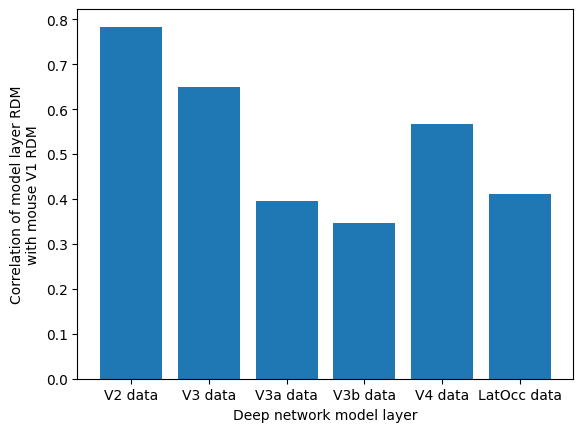

In [ ]:
def correlate_rdms(rdm1, rdm2):
  """Correlate off-diagonal elements of two RDM's

  Args:
    rdm1 (np.ndarray): S x S representational dissimilarity matrix
    rdm2 (np.ndarray): S x S representational dissimilarity matrix to
      correlate with rdm1

  Returns:
    float: correlation coefficient between the off-diagonal elements
      of rdm1 and rdm2

  """

  # Extract off-diagonal elements of each RDM
  ioffdiag = np.triu_indices(rdm1.shape[0], k=1)  # indices of off-diagonal elements
  rdm1_offdiag = rdm1[ioffdiag]
  rdm2_offdiag = rdm2[ioffdiag]

  corr_coef = np.corrcoef(rdm1_offdiag, rdm2_offdiag)[0,1]

  return corr_coef


# Split RDMs into V1 responses and model responses
rdm_model = rdm_dict.copy()
rdm_v1 = rdm_model.pop('V1 data')

# Correlate off-diagonal terms of dissimilarity matrices
rdm_sim = {label: correlate_rdms(rdm_v1, rdm) for label, rdm in rdm_model.items()}

# Visualize
plot_rdm_rdm_correlations(rdm_sim)